In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
loan = pd.read_csv("loan.csv")
loan.head()

,Income,Loan Amount,Default
0,15,8,No
1,30,8,No
2,5,9,Yes
3,22,10,No
4,33,12,No


In [4]:
loan.info()
loan.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Income       30 non-null     int64 
 1   Loan Amount  30 non-null     int64 
 2   Default      30 non-null     object
dtypes: int64(2), object(1)
memory usage: 848.0+ bytes


,Income,Loan Amount
count,30.000000,30.000000
mean,18.766667,51.966667
std,8.572946,34.055212
min,5.000000,8.000000
25%,13.000000,21.250000
50%,18.000000,49.000000
75%,25.500000,79.500000
max,34.000000,110.000000


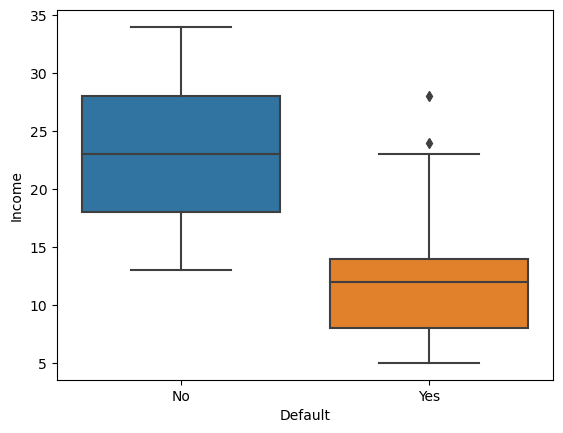

In [5]:
sns.boxplot(data=loan, x='Default', y='Income')
plt.show()

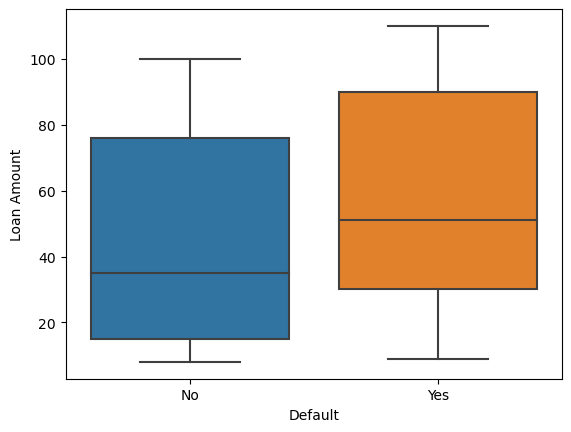

In [6]:
sns.boxplot(data=loan, x='Default', y='Loan Amount')
plt.show()

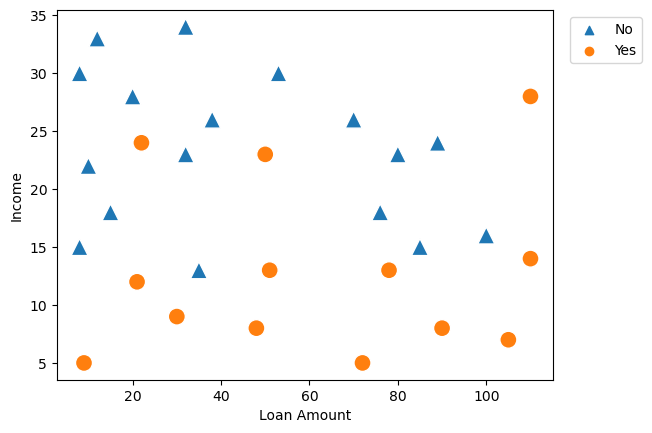

In [7]:
sns.scatterplot(data=loan,
                x='Loan Amount',
                y='Income',
                hue='Default',
                style='Default',
                markers=['^','o'],
                s=150)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

In [8]:
y = loan['Default']              # Target variable
X = loan.drop(columns=['Default'])  # Input features

In [9]:
X = pd.get_dummies(X, drop_first=True)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    stratify=y,
    random_state=1234
)

print(X_train.shape, X_test.shape)

(24, 2) (6, 2)


In [11]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=1234)
model = classifier.fit(X_train, y_train)

In [12]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.5


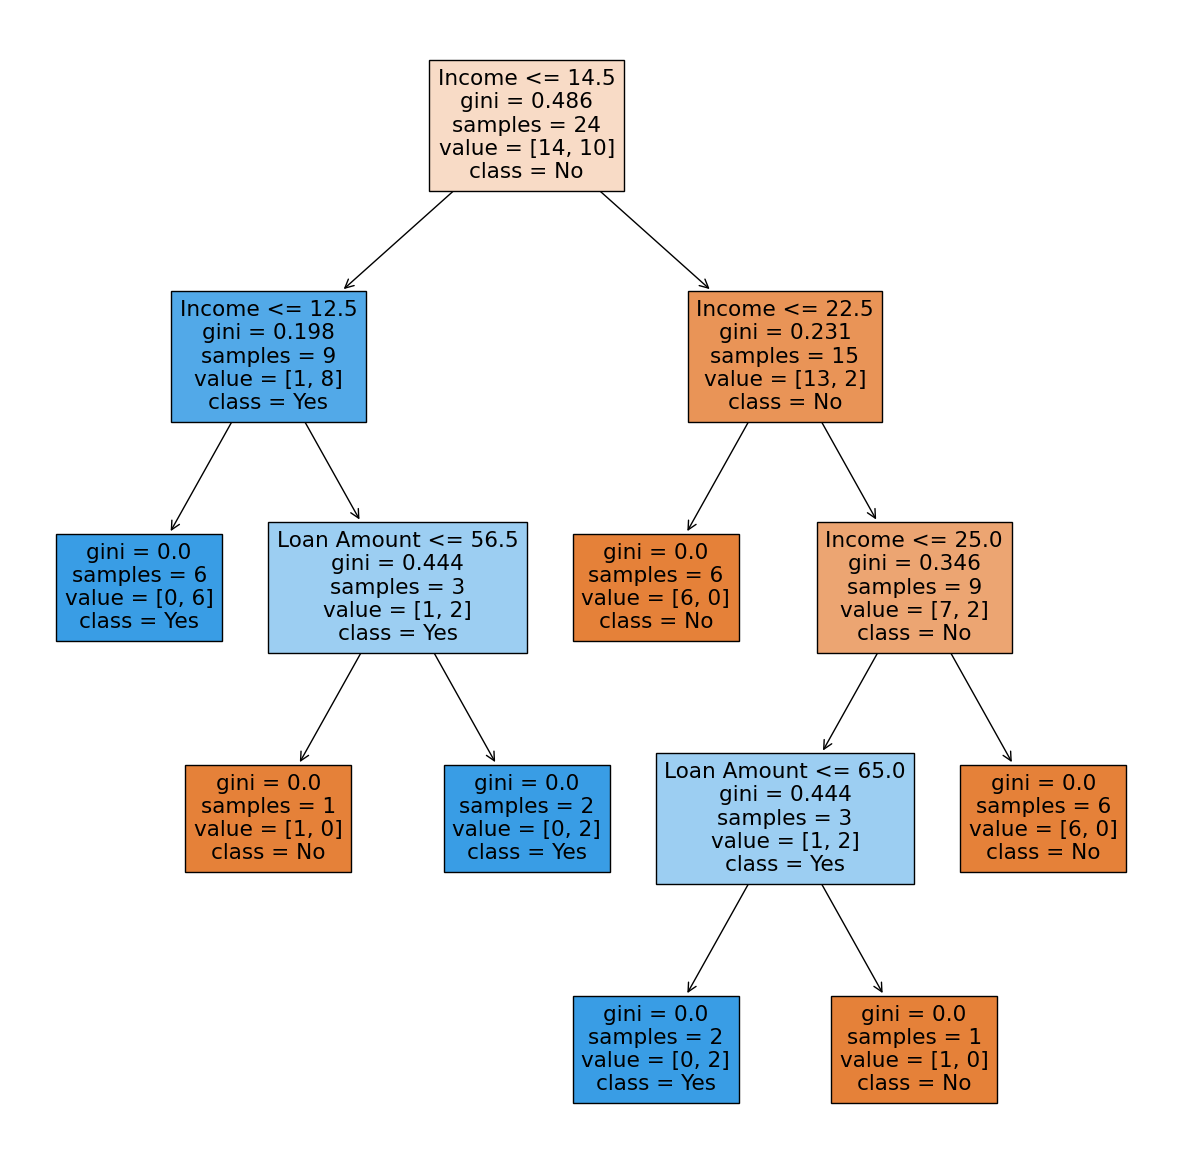

In [13]:
from sklearn import tree

plt.figure(figsize=(15, 15))
tree.plot_tree(model,
               feature_names=X.columns,
               class_names=['No','Yes'],
               filled=True)
plt.show()

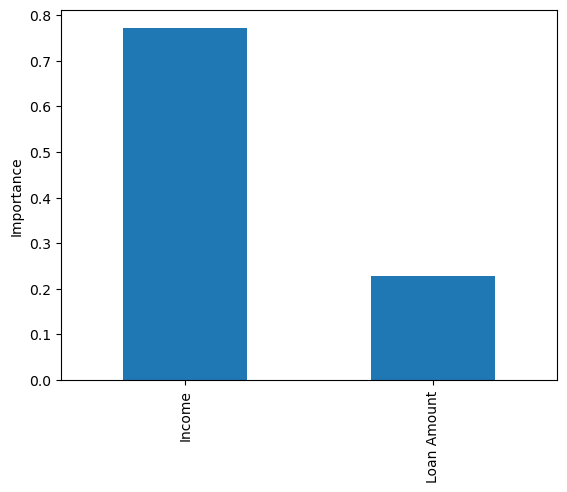

In [14]:
importance = model.feature_importances_

import pandas as pd
feature_importance = pd.Series(importance, index=X.columns)

feature_importance.sort_values(ascending=False).plot(kind='bar')
plt.ylabel('Importance')
plt.show()

In [15]:
from sklearn.model_selection import GridSearchCV

grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

In [16]:
classifier = DecisionTreeClassifier(random_state=1234)

gcv = GridSearchCV(classifier,
                   param_grid=grid,
                   cv=5,
                   scoring='accuracy')

gcv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=1234),
             param_grid={'max_depth': [2, 3, 4, 5, 6],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [17]:
model_ = gcv.best_estimator_

print("Best Parameters:", gcv.best_params_)

Best Parameters: {'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2}


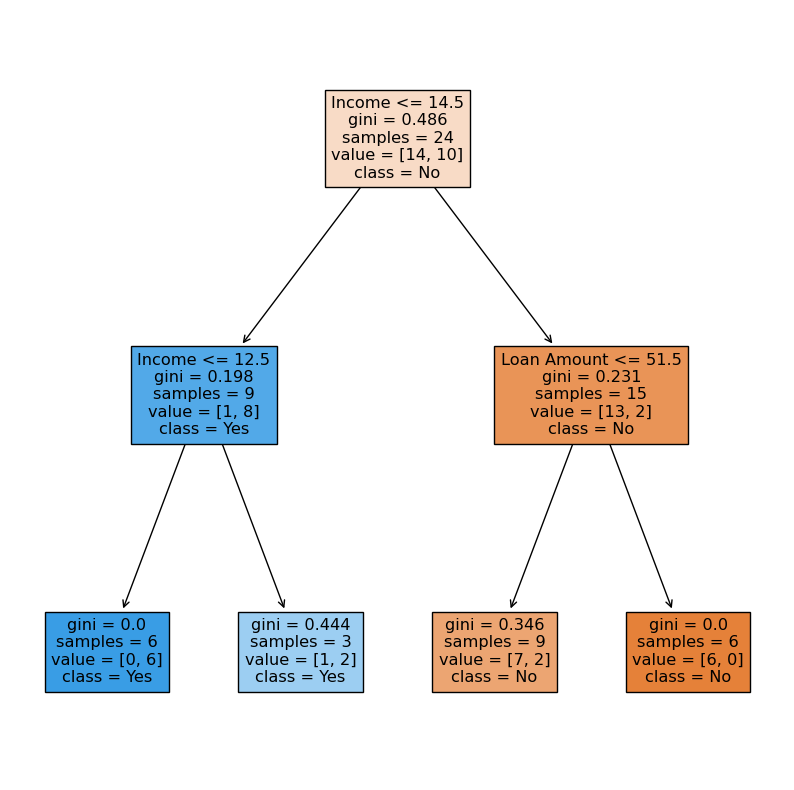

In [18]:
plt.figure(figsize=(10, 10))
tree.plot_tree(model_,
               feature_names=X.columns,
               class_names=['No','Yes'],
               filled=True)
plt.show()